# Hamiltonian replica exchange umbrella sampling

##### Simulation frequencies in Christian's `window_.in` files

In [181]:
output_freq = 10000 # write every <output_freq> MD steps (same unit as "nstlim")
dt = 0.002 # timestep (ps)
writeTimeStep = output_freq * dt # write every <writeTimeStep> ps 
print(writeTimeStep)

nstlim = 1000 # number of steps until an exchange is attempted
exchangeTimeStep = nstlim * dt # attempt an exchange every <exchangeTimeStep> ps 
print(exchangeTimeStep)

numexchg = 5000 # number of exchanges to attempt in a window
total_MDsteps = nstlim * numexchg # total number of MD steps in a window
print(total_MDsteps)

total_MDtime = total_MDsteps * dt # total MD duration (ps) in a window
print(total_MDtime)

numColvDat = total_MDtime / writeTimeStep # number of collective variable data points in a window
print(numColvDat)

20.0
2.0
5000000
10000.0
500.0


WORKING command to start H-REMD umbrella sampling:
```sh
mpirun --oversubscribe -n 10 pmemd.cuda_SPFP.MPI -ng 10 -groupfile groupfile.group -remlog rem.log -rem 3
```

Do NOT use more cores (`--oversubscribe -n`) than the number of groups (`-ng`)\
$\because$ originally got STUCK with
```sh
mpirun --oversubscribe -n 20 pmemd.cuda_SPFP.MPI -ng 10 -groupfile groupfile.group -remlog rem.log -rem 3
```
by following AMBER22 manual (page 519 of 1013):
```sh
mpirun -np 16 sander.MPI -ng 8 -groupfile groupfile -rem 3
```
"Also, _pmemd_ requires at least 2 threads per replica, whereas _sander_ will work with just 1."

BUT\
Christian: `pmemd.cuda` do NOT need 2 CPUs per group

## Analyze umbrella sampled RMSD

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### (NG) Trial 1
GTX 1080 Ti

In [2]:
column_names = ["MD time (ps)", "Collective variable (1:1)"]

rmsd_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

labels = [f"Anchor = {rmsd} Å" for rmsd in rmsd_values]

cmap = plt.get_cmap('viridis')

#### FSC$^{-}$
`B2/7dot10_cont7dot7_replica_2gpu_gtx1080ti`

In [2]:
colv0_receptor_hremd_path = 'B2/7dot10_cont7dot7_replica_2gpu_gtx1080ti/colv0.dat'
colv1_receptor_hremd_path = 'B2/7dot10_cont7dot7_replica_2gpu_gtx1080ti/colv1.dat'
colv2_receptor_hremd_path = 'B2/7dot10_cont7dot7_replica_2gpu_gtx1080ti/colv2.dat'
colv3_receptor_hremd_path = 'B2/7dot10_cont7dot7_replica_2gpu_gtx1080ti/colv3.dat'
colv4_receptor_hremd_path = 'B2/7dot10_cont7dot7_replica_2gpu_gtx1080ti/colv4.dat'
colv5_receptor_hremd_path = 'B2/7dot10_cont7dot7_replica_2gpu_gtx1080ti/colv5.dat'
colv6_receptor_hremd_path = 'B2/7dot10_cont7dot7_replica_2gpu_gtx1080ti/colv6.dat'
colv7_receptor_hremd_path = 'B2/7dot10_cont7dot7_replica_2gpu_gtx1080ti/colv7.dat'
colv8_receptor_hremd_path = 'B2/7dot10_cont7dot7_replica_2gpu_gtx1080ti/colv8.dat'
colv9_receptor_hremd_path = 'B2/7dot10_cont7dot7_replica_2gpu_gtx1080ti/colv9.dat'

colv0_receptor_hremd_df = pd.read_csv(colv0_receptor_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_receptor_hremd_df)

colv1_receptor_hremd_df = pd.read_csv(colv1_receptor_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_receptor_hremd_df = pd.read_csv(colv2_receptor_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_receptor_hremd_df = pd.read_csv(colv3_receptor_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_receptor_hremd_df = pd.read_csv(colv4_receptor_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_receptor_hremd_df = pd.read_csv(colv5_receptor_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_receptor_hremd_df = pd.read_csv(colv6_receptor_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_receptor_hremd_df = pd.read_csv(colv7_receptor_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_receptor_hremd_df = pd.read_csv(colv8_receptor_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_receptor_hremd_df = pd.read_csv(colv9_receptor_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,14000.0,1.305449
1,14001.0,1.325780
2,14002.0,1.306679
3,14003.0,1.363500
4,14004.0,1.390725
...,...,...
9995,23995.0,1.383720
9996,23996.0,1.412387
9997,23997.0,1.435809
9998,23998.0,1.502625


In [4]:
receptor_df_list = [colv0_receptor_hremd_df, colv1_receptor_hremd_df, colv2_receptor_hremd_df, colv3_receptor_hremd_df, colv4_receptor_hremd_df, colv5_receptor_hremd_df, colv6_receptor_hremd_df, colv7_receptor_hremd_df, colv8_receptor_hremd_df, colv9_receptor_hremd_df]

colors = cmap(np.linspace(0, 1, len(receptor_df_list)))

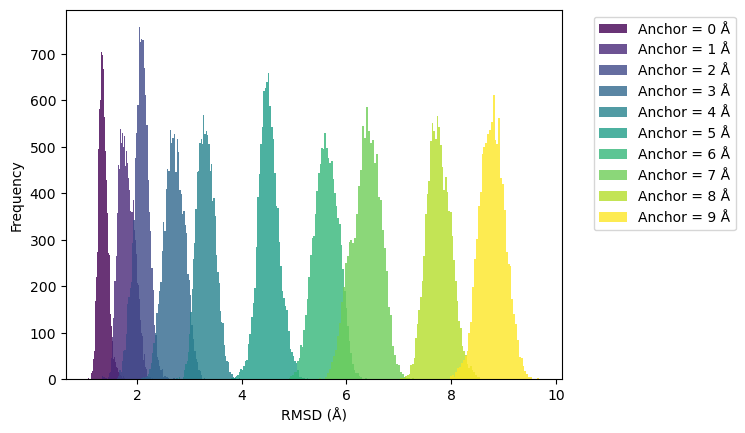

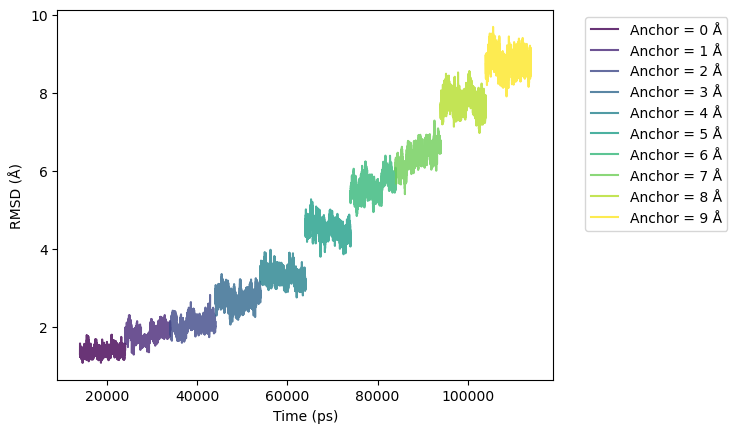

In [5]:
for df, label, color in zip(receptor_df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(receptor_df_list, labels, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

BARELY enough windows!

REPEAT with 0.5 Å `anchor_position` separation for RMSD > 4 Å

#### (NG) FSC$^{+}$
`B2/9dot30_cont9dot24_replica_2gtx1080ti_dat`

WRONG `9md` coordinates (used FSC$^{-}$)

In [3]:
colv0_RLS_hremd_path = 'B2/9dot30_cont9dot24_replica_2gtx1080ti_dat/colv0.dat'
colv1_RLS_hremd_path = 'B2/9dot30_cont9dot24_replica_2gtx1080ti_dat/colv1.dat'
colv2_RLS_hremd_path = 'B2/9dot30_cont9dot24_replica_2gtx1080ti_dat/colv2.dat'
colv3_RLS_hremd_path = 'B2/9dot30_cont9dot24_replica_2gtx1080ti_dat/colv3.dat'
colv4_RLS_hremd_path = 'B2/9dot30_cont9dot24_replica_2gtx1080ti_dat/colv4.dat'
colv5_RLS_hremd_path = 'B2/9dot30_cont9dot24_replica_2gtx1080ti_dat/colv5.dat'
colv6_RLS_hremd_path = 'B2/9dot30_cont9dot24_replica_2gtx1080ti_dat/colv6.dat'
colv7_RLS_hremd_path = 'B2/9dot30_cont9dot24_replica_2gtx1080ti_dat/colv7.dat'
colv8_RLS_hremd_path = 'B2/9dot30_cont9dot24_replica_2gtx1080ti_dat/colv8.dat'
colv9_RLS_hremd_path = 'B2/9dot30_cont9dot24_replica_2gtx1080ti_dat/colv9.dat'

colv0_RLS_hremd_df = pd.read_csv(colv0_RLS_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_RLS_hremd_df)

colv1_RLS_hremd_df = pd.read_csv(colv1_RLS_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_RLS_hremd_df = pd.read_csv(colv2_RLS_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_RLS_hremd_df = pd.read_csv(colv3_RLS_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_RLS_hremd_df = pd.read_csv(colv4_RLS_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_RLS_hremd_df = pd.read_csv(colv5_RLS_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_RLS_hremd_df = pd.read_csv(colv6_RLS_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_RLS_hremd_df = pd.read_csv(colv7_RLS_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_RLS_hremd_df = pd.read_csv(colv8_RLS_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_RLS_hremd_df = pd.read_csv(colv9_RLS_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,14000.0,1.578521
1,14001.0,1.536304
2,14002.0,1.534171
3,14003.0,1.554699
4,14004.0,1.549552
...,...,...
9995,23995.0,1.226603
9996,23996.0,1.352993
9997,23997.0,1.374339
9998,23998.0,1.405773


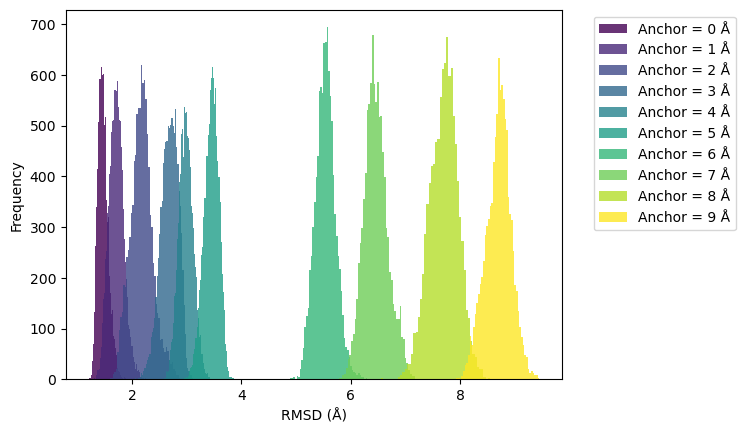

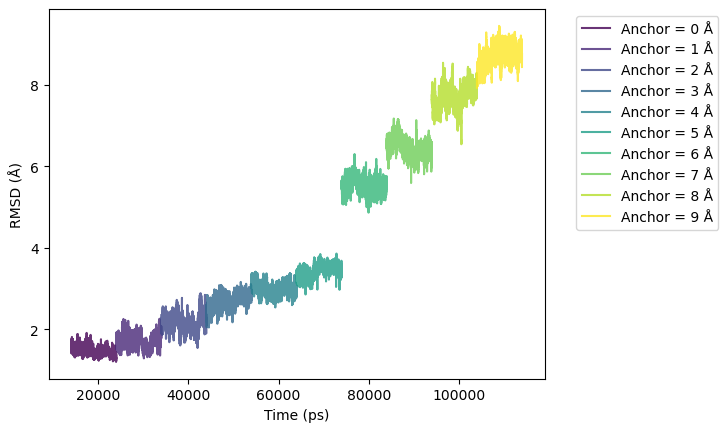

In [4]:
receptor_df_list = [colv0_RLS_hremd_df, colv1_RLS_hremd_df, colv2_RLS_hremd_df, colv3_RLS_hremd_df, colv4_RLS_hremd_df, colv5_RLS_hremd_df, colv6_RLS_hremd_df, colv7_RLS_hremd_df, colv8_RLS_hremd_df, colv9_RLS_hremd_df]

colors = cmap(np.linspace(0, 1, len(receptor_df_list)))

# Plot each dataframe with a different color
for df, label, color in zip(receptor_df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(receptor_df_list, labels, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

NOT enough windows\
BUT can the gap be covered with just 1 more window at 5.5 Å RMSD?

#### (NG) Free energy comparison
`wham 0 10 100 0.01 310 0 meta.dat result_bootstrap.dat 100 42`

In [5]:
colv_hremd_free_path = 'B2/7dot10_cont7dot7_replica_2gpu_gtx1080ti/result_bootstrap.dat'
colv_FSC_hremd_free_path = 'B2/9dot30_cont9dot24_replica_2gtx1080ti_dat/result_bootstrap.dat'

# Read the data, skipping the first row (header), drop rows, filter 'inf' and convert columns to numeric
colv_hremd_free_df = (pd.read_csv(colv_hremd_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))
display(colv_hremd_free_df)
colv_FSC_hremd_free_df = (pd.read_csv(colv_FSC_hremd_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))
display(colv_FSC_hremd_free_df)

,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,NaN,NaN,0.0,0.0
1,0.15,NaN,NaN,0.0,0.0
2,0.25,NaN,NaN,0.0,0.0
3,0.35,NaN,NaN,0.0,0.0
4,0.45,NaN,NaN,0.0,0.0
...,...,...,...,...,...
95,9.55,25.448149,0.269822,0.0,0.0
96,9.65,25.523472,NaN,0.0,0.0
97,9.75,NaN,NaN,0.0,0.0
98,9.85,NaN,NaN,0.0,0.0


,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,NaN,NaN,0.0,0.0
1,0.15,NaN,NaN,0.0,0.0
2,0.25,NaN,NaN,0.0,0.0
3,0.35,NaN,NaN,0.0,0.0
4,0.45,NaN,NaN,0.0,0.0
...,...,...,...,...,...
95,9.55,NaN,NaN,0.0,0.0
96,9.65,NaN,NaN,0.0,0.0
97,9.75,NaN,NaN,0.0,0.0
98,9.85,NaN,NaN,0.0,0.0


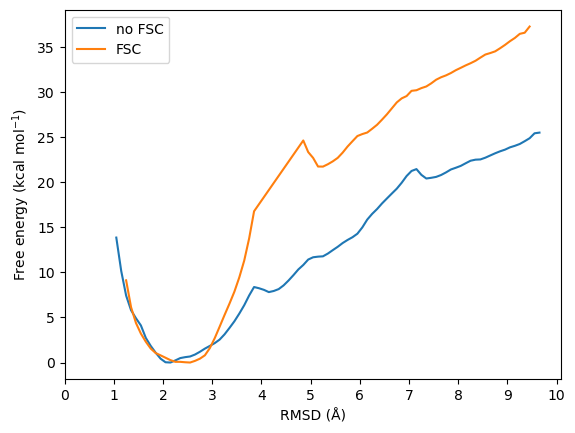

In [6]:
sns.lineplot(x='Coor', y='Free', data=colv_hremd_free_df, label='no FSC')
sns.lineplot(x='Coor', y='Free', data=colv_FSC_hremd_free_df, label='FSC')
plt.xlabel('RMSD (Å)')
plt.ylabel('Free energy (kcal mol$^{-1}$)')
plt.xticks(np.arange(0, 11, step=1))
plt.show()

### (NG) Trial 2
1. more windows 
2. GTX 1080 Ti

In [17]:
column_names = ["MD time (ps)", "Collective variable (1:1)"]

rmsd_values_addWindow = [0, 1, 2, 3, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9]

labels_addWindow = [f"Anchor = {rmsd} Å" for rmsd in rmsd_values_addWindow]

cmap_addWindow = plt.get_cmap('viridis')

#### FSC$^{-}$
`B2/7dot11_cont7dot7_addWindow_replica_dat`

In [18]:
colv0_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv0.dat'
colv1_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv1.dat'
colv2_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv2.dat'
colv3_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv3.dat'
colv4_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv4.dat'
colv4dot5_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv4dot5.dat'
colv5_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv5.dat'
colv5dot5_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv5dot5.dat'
colv6_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv6.dat'
colv6dot5_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv6dot5.dat'
colv7_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv7.dat'
colv7dot5_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv7dot5.dat'
colv8_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv8.dat'
colv8dot5_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv8dot5.dat'
colv9_hremd_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/colv9.dat'

colv0_hremd_df = pd.read_csv(colv0_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_hremd_df)

colv1_hremd_df = pd.read_csv(colv1_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_hremd_df = pd.read_csv(colv2_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_hremd_df = pd.read_csv(colv3_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_hremd_df = pd.read_csv(colv4_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4dot5_hremd_df = pd.read_csv(colv4dot5_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_hremd_df = pd.read_csv(colv5_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5dot5_hremd_df = pd.read_csv(colv5dot5_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_hremd_df = pd.read_csv(colv6_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6dot5_hremd_df = pd.read_csv(colv6dot5_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_hremd_df = pd.read_csv(colv7_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7dot5_hremd_df = pd.read_csv(colv7dot5_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_hremd_df = pd.read_csv(colv8_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8dot5_hremd_df = pd.read_csv(colv8dot5_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_hremd_df = pd.read_csv(colv9_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,14000.0,1.305449
1,14001.0,1.325780
2,14002.0,1.306679
3,14003.0,1.363500
4,14004.0,1.390725
...,...,...
9995,23995.0,1.559167
9996,23996.0,1.444551
9997,23997.0,1.498343
9998,23998.0,1.529806


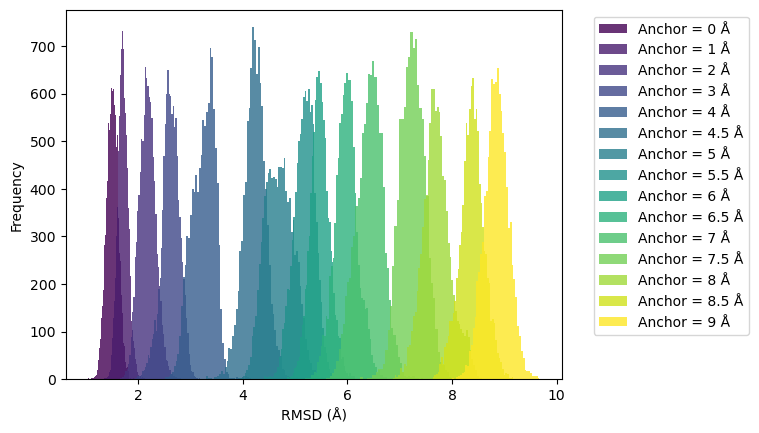

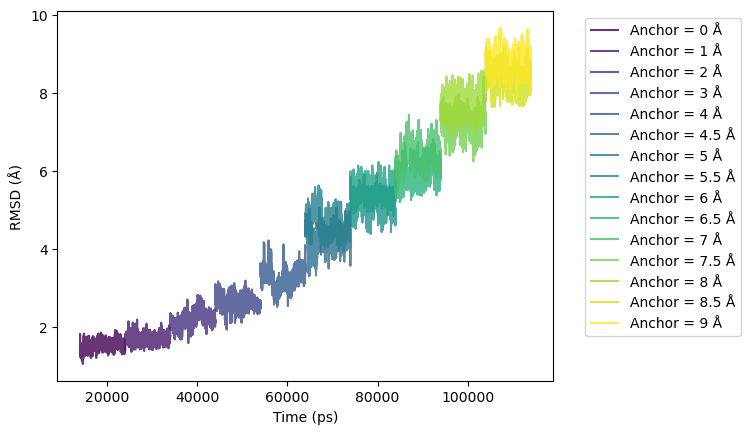

In [19]:
colv_df_list = [colv0_hremd_df, colv1_hremd_df, colv2_hremd_df, colv3_hremd_df, colv4_hremd_df, colv4dot5_hremd_df, colv5_hremd_df, colv5dot5_hremd_df, colv6_hremd_df, colv6dot5_hremd_df, colv7_hremd_df, colv7dot5_hremd_df, colv8_hremd_df, colv8dot5_hremd_df, colv9_hremd_df]

colors = cmap_addWindow(np.linspace(0, 1, len(colv_df_list)))

for df, label, color in zip(colv_df_list, labels_addWindow, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(colv_df_list, labels_addWindow, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### (NG) FSC$^{+}$
`B2/9dot31_cont9dot24_replica_addWindow_dat`

WRONG `9md` coordinates (used FSC$^{-}$)

In [7]:
colv0_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv0.dat'
colv1_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv1.dat'
colv2_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv2.dat'
colv3_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv3.dat'
colv4_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv4.dat'
colv4dot5_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv4dot5.dat'
colv5_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv5.dat'
colv5dot5_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv5dot5.dat'
colv6_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv6.dat'
colv6dot5_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv6dot5.dat'
colv7_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv7.dat'
colv7dot5_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv7dot5.dat'
colv8_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv8.dat'
colv8dot5_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv8dot5.dat'
colv9_FSC_hremd_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/colv9.dat'

colv0_FSC_hremd_df = pd.read_csv(colv0_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_FSC_hremd_df)

colv1_FSC_hremd_df = pd.read_csv(colv1_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_FSC_hremd_df = pd.read_csv(colv2_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_FSC_hremd_df = pd.read_csv(colv3_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_FSC_hremd_df = pd.read_csv(colv4_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4dot5_FSC_hremd_df = pd.read_csv(colv4dot5_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_FSC_hremd_df = pd.read_csv(colv5_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5dot5_FSC_hremd_df = pd.read_csv(colv5dot5_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_FSC_hremd_df = pd.read_csv(colv6_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6dot5_FSC_hremd_df = pd.read_csv(colv6dot5_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_FSC_hremd_df = pd.read_csv(colv7_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7dot5_FSC_hremd_df = pd.read_csv(colv7dot5_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_FSC_hremd_df = pd.read_csv(colv8_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8dot5_FSC_hremd_df = pd.read_csv(colv8dot5_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_FSC_hremd_df = pd.read_csv(colv9_FSC_hremd_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,14000.0,1.578521
1,14001.0,1.536304
2,14002.0,1.534171
3,14003.0,1.554699
4,14004.0,1.549552
...,...,...
9995,23995.0,1.564416
9996,23996.0,1.548120
9997,23997.0,1.513469
9998,23998.0,1.472557


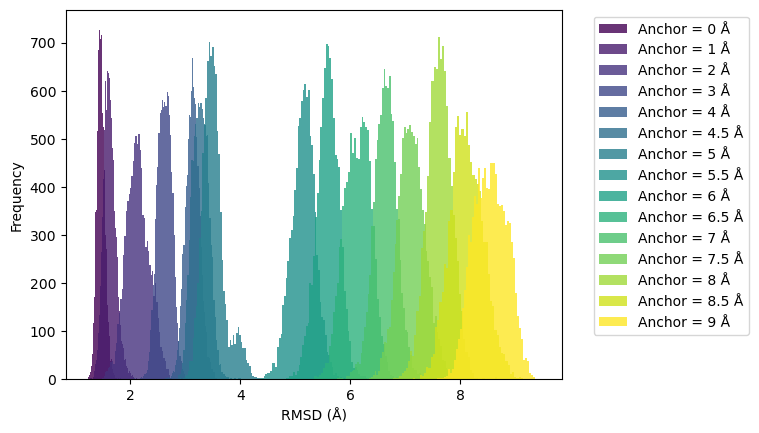

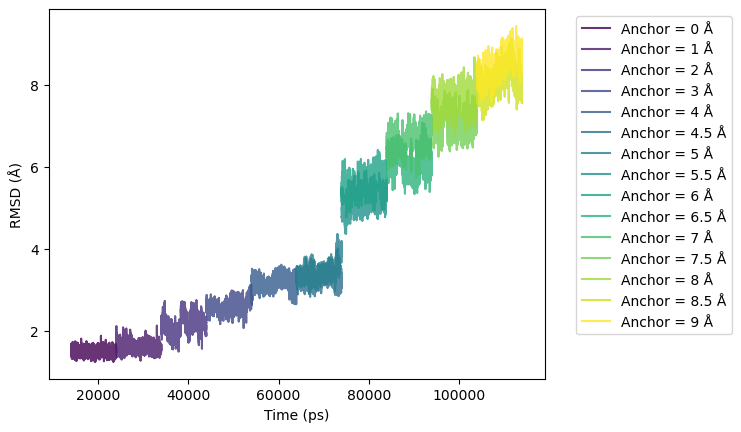

In [16]:
colv_df_list = [colv0_FSC_hremd_df, colv1_FSC_hremd_df, colv2_FSC_hremd_df, colv3_FSC_hremd_df, colv4_FSC_hremd_df, colv4dot5_FSC_hremd_df, colv5_FSC_hremd_df, colv5dot5_FSC_hremd_df, colv6_FSC_hremd_df, colv6dot5_FSC_hremd_df, colv7_FSC_hremd_df, colv7dot5_FSC_hremd_df, colv8_FSC_hremd_df, colv8dot5_FSC_hremd_df, colv9_FSC_hremd_df]

colors = cmap_addWindow(np.linspace(0, 1, len(colv_df_list)))

# Plot each dataframe with a different color
for df, label, color in zip(colv_df_list, labels_addWindow, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

for df, label, color in zip(colv_df_list, labels_addWindow, colors):
    sns.lineplot(data=df, x="MD time (ps)", y="Collective variable (1:1)", label=label, alpha=0.8, color=color)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### (NG) Free energy comparison
`wham 0 10 100 0.01 310 0 meta.dat result_bootstrap.dat 100 42`

In [21]:
colv_hremd_free_path = 'B2/7dot11_cont7dot7_addWindow_replica_dat/result_bootstrap.dat'
colv_FSC_hremd_free_path = 'B2/9dot31_cont9dot24_replica_addWindow_dat/result_bootstrap.dat'

colv_hremd_free_df = (pd.read_csv(colv_hremd_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))
display(colv_hremd_free_df)
colv_FSC_hremd_free_df = (pd.read_csv(colv_FSC_hremd_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))
display(colv_FSC_hremd_free_df)

,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,NaN,NaN,0.0,0.0
1,0.15,NaN,NaN,0.0,0.0
2,0.25,NaN,NaN,0.0,0.0
3,0.35,NaN,NaN,0.0,0.0
4,0.45,NaN,NaN,0.0,0.0
...,...,...,...,...,...
95,9.55,25.794698,0.125208,0.0,0.0
96,9.65,25.771286,0.197192,0.0,0.0
97,9.75,NaN,NaN,0.0,0.0
98,9.85,NaN,NaN,0.0,0.0


,Coor,Free,+/-Free,Prob,+/-Prob
0,0.05,NaN,NaN,0.0,0.0
1,0.15,NaN,NaN,0.0,0.0
2,0.25,NaN,NaN,0.0,0.0
3,0.35,NaN,NaN,0.0,0.0
4,0.45,NaN,NaN,0.0,0.0
...,...,...,...,...,...
95,9.55,NaN,NaN,0.0,0.0
96,9.65,NaN,NaN,0.0,0.0
97,9.75,NaN,NaN,0.0,0.0
98,9.85,NaN,NaN,0.0,0.0


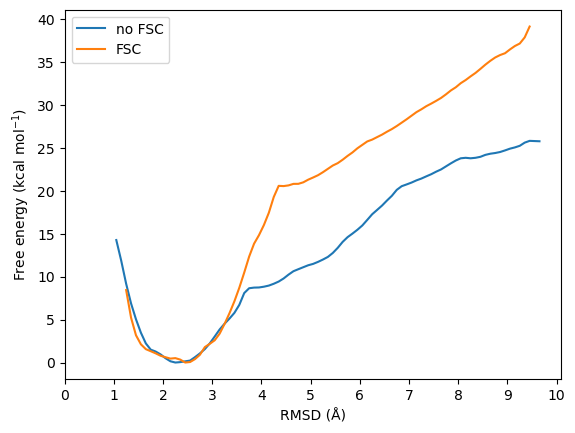

In [22]:
sns.lineplot(x='Coor', y='Free', data=colv_hremd_free_df, label='no FSC')
sns.lineplot(x='Coor', y='Free', data=colv_FSC_hremd_free_df, label='FSC')
plt.xlabel('RMSD (Å)')
plt.ylabel('Free energy (kcal mol$^{-1}$)')
plt.xticks(np.arange(0, 11, step=1))
plt.show()

### Trial 3

Restrain & sample only the RMSD of receptor interface atoms in the RL(S) complex!\
$\rightarrow$ comparable to the R(S) system?

ALSO try restraining just the ligand interface atoms!\
$\rightarrow$ how much does ligand contribute to the free energy?\
$\because$ ligand is also in contact (although slighty lesser) with FSC

In [17]:
column_names = ["MD time (ps)", "Collective variable (1:1)"]
cmap = plt.get_cmap('viridis')

#### FSC$^{+}$

In [4]:
colv0_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv0.dat'
colv1_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv1.dat'
colv2_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv2.dat'
colv3_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv3.dat'
colv4_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv4.dat'
colv4dot25_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv4dot25.dat'
colv4dot5_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv4dot5.dat'
colv4dot75_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv4dot75.dat'
colv5_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv5.dat'
colv5dot25_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv5dot25.dat'
colv5dot5_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv5dot5.dat'
colv5dot75_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv5dot75.dat'
colv6_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv6.dat'
colv7_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv7.dat'
colv8_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv8.dat'
colv9_repEx_FSC_Rint_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/colv9.dat'

colv0_repEx_FSC_Rint_df = pd.read_csv(colv0_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_repEx_FSC_Rint_df)

colv1_repEx_FSC_Rint_df = pd.read_csv(colv1_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_repEx_FSC_Rint_df = pd.read_csv(colv2_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_repEx_FSC_Rint_df = pd.read_csv(colv3_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_repEx_FSC_Rint_df = pd.read_csv(colv4_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4dot25_repEx_FSC_Rint_df = pd.read_csv(colv4dot25_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4dot5_repEx_FSC_Rint_df = pd.read_csv(colv4dot5_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4dot75_repEx_FSC_Rint_df = pd.read_csv(colv4dot75_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_repEx_FSC_Rint_df = pd.read_csv(colv5_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5dot25_repEx_FSC_Rint_df = pd.read_csv(colv5dot25_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5dot5_repEx_FSC_Rint_df = pd.read_csv(colv5dot5_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5dot75_repEx_FSC_Rint_df = pd.read_csv(colv5dot75_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_repEx_FSC_Rint_df = pd.read_csv(colv6_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_repEx_FSC_Rint_df = pd.read_csv(colv7_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_repEx_FSC_Rint_df = pd.read_csv(colv8_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_repEx_FSC_Rint_df = pd.read_csv(colv9_repEx_FSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)

,MD time (ps),Collective variable (1:1)
0,14000.0,0.876608
1,14001.0,0.899437
2,14002.0,0.813949
3,14003.0,0.899256
4,14004.0,0.961363
...,...,...
9995,23995.0,1.102994
9996,23996.0,1.114605
9997,23997.0,1.145477
9998,23998.0,1.098155


##### All windows

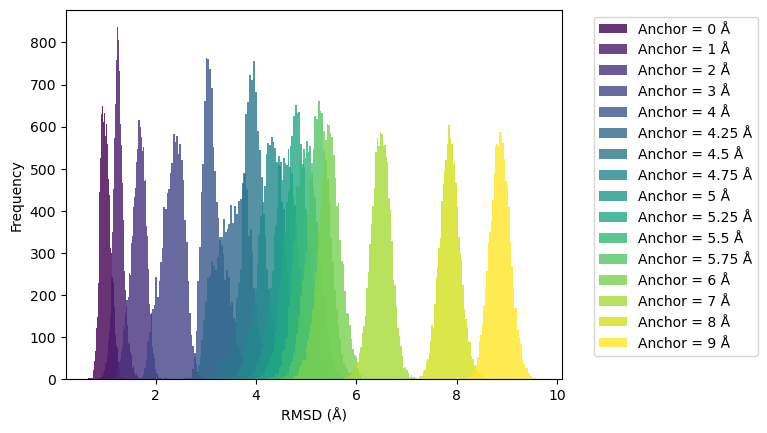

In [23]:
rmsd_values_FSC = [0, 1, 2, 3, 
               4, 
               4.25, 
               4.5, 
               4.75, 
               5, 
               5.25, 
               5.5, 
               5.75, 
               6, 7, 8, 9]
labels = [f"Anchor = {rmsd} Å" for rmsd in rmsd_values_FSC]

colv_repEx_FSC_Rint_df_list = [colv0_repEx_FSC_Rint_df, colv1_repEx_FSC_Rint_df, colv2_repEx_FSC_Rint_df, colv3_repEx_FSC_Rint_df, 
                               colv4_repEx_FSC_Rint_df, 
                               colv4dot25_repEx_FSC_Rint_df, 
                               colv4dot5_repEx_FSC_Rint_df, 
                               colv4dot75_repEx_FSC_Rint_df, 
                               colv5_repEx_FSC_Rint_df, 
                               colv5dot25_repEx_FSC_Rint_df, 
                               colv5dot5_repEx_FSC_Rint_df, 
                               colv5dot75_repEx_FSC_Rint_df, 
                               colv6_repEx_FSC_Rint_df, colv7_repEx_FSC_Rint_df, colv8_repEx_FSC_Rint_df, colv9_repEx_FSC_Rint_df]

colors = cmap(np.linspace(0, 1, len(colv_repEx_FSC_Rint_df_list)))

for df, label, color in zip(colv_repEx_FSC_Rint_df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##### Remove intermediate windows

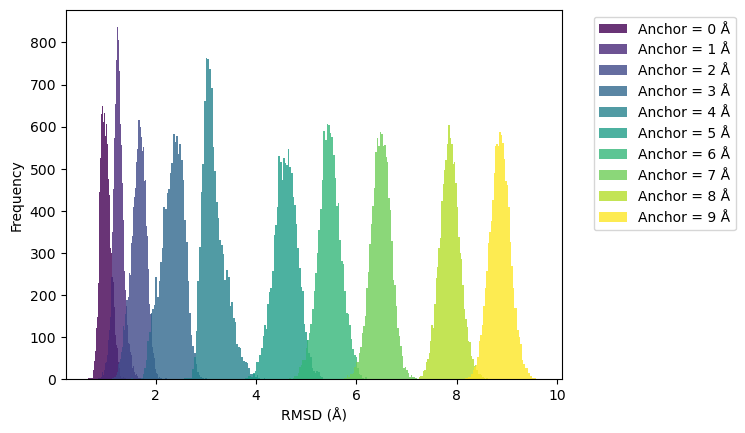

In [36]:
rmsd_values_FSC = [0, 1, 2, 3, 
               4, 
               # 4.25, 
               # 4.5, 
               # 4.75, 
               5, 
               # 5.25, 
               # 5.5, 
               # 5.75, 
               6, 7, 8, 9]

labels = [f"Anchor = {rmsd} Å" for rmsd in rmsd_values_FSC]

colv_repEx_FSC_Rint_df_list = [colv0_repEx_FSC_Rint_df, colv1_repEx_FSC_Rint_df, colv2_repEx_FSC_Rint_df, colv3_repEx_FSC_Rint_df, 
                               colv4_repEx_FSC_Rint_df, 
                               # colv4dot25_repEx_FSC_Rint_df, 
                               # colv4dot5_repEx_FSC_Rint_df, 
                               # colv4dot75_repEx_FSC_Rint_df, 
                               colv5_repEx_FSC_Rint_df, 
                               # colv5dot25_repEx_FSC_Rint_df, 
                               # colv5dot5_repEx_FSC_Rint_df, 
                               # colv5dot75_repEx_FSC_Rint_df, 
                               colv6_repEx_FSC_Rint_df, colv7_repEx_FSC_Rint_df, colv8_repEx_FSC_Rint_df, colv9_repEx_FSC_Rint_df]

colors = cmap(np.linspace(0, 1, len(colv_repEx_FSC_Rint_df_list)))

for df, label, color in zip(colv_repEx_FSC_Rint_df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### FSC$^{-}$

In [ ]:
colv0_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv0.dat'
colv1_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv1.dat'
colv2_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv2.dat'
colv3_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv3.dat'
colv4_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv4.dat'
colv4dot25_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv4dot25.dat'
colv4dot5_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv4dot5.dat'
colv4dot75_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv4dot75.dat'
colv5_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv5.dat'
colv5dot25_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv5dot25.dat'
colv5dot5_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv5dot5.dat'
colv5dot75_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv5dot75.dat'
colv6_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv6.dat'
colv7_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv7.dat'
colv8_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv8.dat'
colv9_repEx_noFSC_Rint_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/colv9.dat'

colv0_repEx_noFSC_Rint_df = pd.read_csv(colv0_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_repEx_noFSC_Rint_df)

colv1_repEx_noFSC_Rint_df = pd.read_csv(colv1_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv2_repEx_noFSC_Rint_df = pd.read_csv(colv2_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv3_repEx_noFSC_Rint_df = pd.read_csv(colv3_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4_repEx_noFSC_Rint_df = pd.read_csv(colv4_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4dot25_repEx_noFSC_Rint_df = pd.read_csv(colv4dot25_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4dot5_repEx_noFSC_Rint_df = pd.read_csv(colv4dot5_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv4dot75_repEx_noFSC_Rint_df = pd.read_csv(colv4dot75_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5_repEx_noFSC_Rint_df = pd.read_csv(colv5_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5dot25_repEx_noFSC_Rint_df = pd.read_csv(colv5dot25_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5dot5_repEx_noFSC_Rint_df = pd.read_csv(colv5dot5_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv5dot75_repEx_noFSC_Rint_df = pd.read_csv(colv5dot75_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv6_repEx_noFSC_Rint_df = pd.read_csv(colv6_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv7_repEx_noFSC_Rint_df = pd.read_csv(colv7_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv8_repEx_noFSC_Rint_df = pd.read_csv(colv8_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)
colv9_repEx_noFSC_Rint_df = pd.read_csv(colv9_repEx_noFSC_Rint_path, comment='#', delim_whitespace=True, header=None, names=column_names)

##### All windows

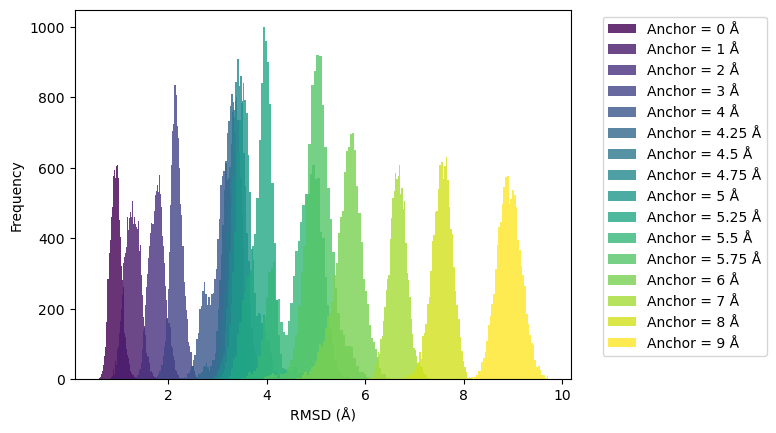

In [40]:
rmsd_values_noFSC = [0, 1, 2, 3, 
               4, 
               4.25, 
               4.5, 
               4.75, 
               5, 
               5.25, 
               5.5, 
               5.75, 
               6, 7, 8, 9]

labels = [f"Anchor = {rmsd} Å" for rmsd in rmsd_values_noFSC]

colv_repEx_noFSC_Rint_df_list = [colv0_repEx_noFSC_Rint_df, colv1_repEx_noFSC_Rint_df, colv2_repEx_noFSC_Rint_df, colv3_repEx_noFSC_Rint_df, 
                               colv4_repEx_noFSC_Rint_df, 
                               colv4dot25_repEx_noFSC_Rint_df, 
                                colv4dot5_repEx_noFSC_Rint_df, 
                               colv4dot75_repEx_noFSC_Rint_df, 
                               colv5_repEx_noFSC_Rint_df, 
                               colv5dot25_repEx_noFSC_Rint_df, 
                                colv5dot5_repEx_noFSC_Rint_df, 
                               colv5dot75_repEx_noFSC_Rint_df, 
                               colv6_repEx_noFSC_Rint_df, colv7_repEx_noFSC_Rint_df, colv8_repEx_noFSC_Rint_df, colv9_repEx_noFSC_Rint_df]

colors = cmap(np.linspace(0, 1, len(colv_repEx_noFSC_Rint_df_list)))

for df, label, color in zip(colv_repEx_noFSC_Rint_df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##### Remove intermediate windows

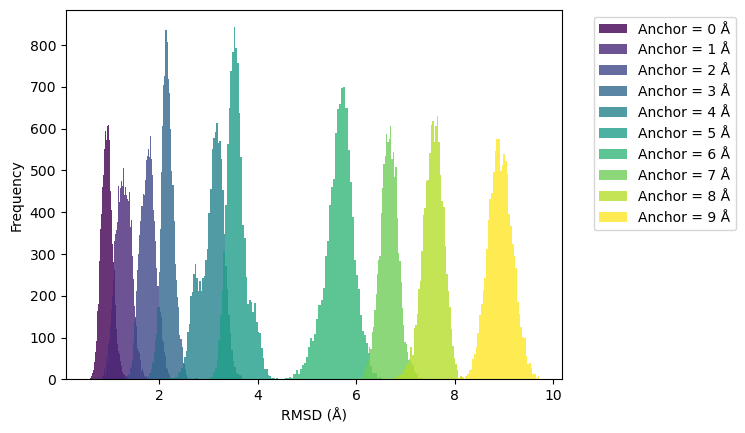

In [37]:
rmsd_values_noFSC = [0, 1, 2, 3, 
               4, 
               # 4.25, 
               # 4.5, 
               # 4.75, 
               5, 
               # 5.25, 
               # 5.5, 
               # 5.75, 
               6, 7, 8, 9]
labels = [f"Anchor = {rmsd} Å" for rmsd in rmsd_values_noFSC]

colv_repEx_noFSC_Rint_df_list = [colv0_repEx_noFSC_Rint_df, colv1_repEx_noFSC_Rint_df, colv2_repEx_noFSC_Rint_df, colv3_repEx_noFSC_Rint_df, 
                               colv4_repEx_noFSC_Rint_df, 
                               # colv4dot25_repEx_noFSC_Rint_df, 
                               #  colv4dot5_repEx_noFSC_Rint_df, 
                               # colv4dot75_repEx_noFSC_Rint_df, 
                               colv5_repEx_noFSC_Rint_df, 
                               # colv5dot25_repEx_noFSC_Rint_df, 
                               #  colv5dot5_repEx_noFSC_Rint_df, 
                               # colv5dot75_repEx_noFSC_Rint_df, 
                               colv6_repEx_noFSC_Rint_df, colv7_repEx_noFSC_Rint_df, colv8_repEx_noFSC_Rint_df, colv9_repEx_noFSC_Rint_df]

colors = cmap(np.linspace(0, 1, len(colv_repEx_noFSC_Rint_df_list)))

for df, label, color in zip(colv_repEx_noFSC_Rint_df_list, labels, colors):
    sns.histplot(df["Collective variable (1:1)"], bins=50, label=label, alpha=0.8, color=color, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Free energy comparison

##### (NG) all windows
Sudden jump in free energy $\rightarrow$ NG window overlap

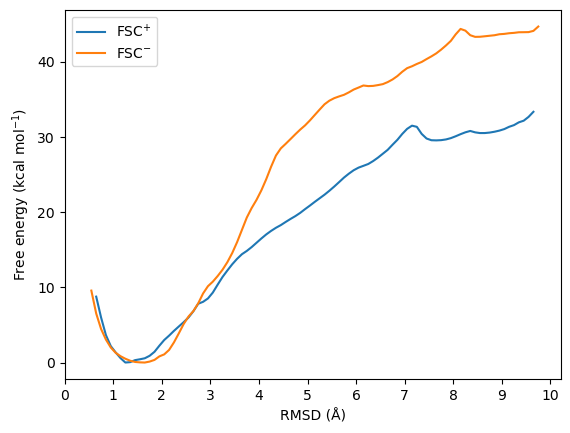

In [27]:
colv_repEx_FSC_Rint_free_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/result_bootstrap.dat'
colv_repEx_noFSC_Rint_free_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/result_bootstrap.dat'

# Read the data, skipping the first row (header), drop rows, filter 'inf' and convert columns to numeric
colv_repEx_FSC_Rint_free_df = (pd.read_csv(colv_repEx_FSC_Rint_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))

colv_repEx_noFSC_Rint_free_df = (pd.read_csv(colv_repEx_noFSC_Rint_free_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))


sns.lineplot(x='Coor', y='Free', data=colv_repEx_FSC_Rint_free_df, label='FSC$^{+}$')
sns.lineplot(x='Coor', y='Free', data=colv_repEx_noFSC_Rint_free_df, label='FSC$^{-}$')
plt.xlabel('RMSD (Å)')
plt.ylabel('Free energy (kcal mol$^{-1}$)')
plt.xticks(np.arange(0, 11, step=1))
plt.show()

##### remove windows colv8 and colv9

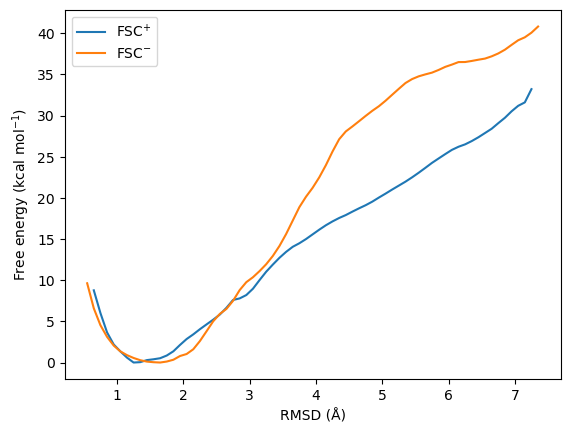

In [29]:
colv_repEx_FSC_Rint_free7_path = 'B2/receptor_ligand_FSC/prod_hremd_colv_receptor_interface_ligand_FSC/result_bootstrap_colv7.dat'
colv_repEx_noFSC_Rint_free7_path = 'B2/receptor_ligand/prod_hremd_colv_receptor_interface_ligand/result_bootstrap_colv7.dat'

# Read the data, skipping the first row (header), drop rows, filter 'inf' and convert columns to numeric
colv_repEx_FSC_Rint_free7_df = (pd.read_csv(colv_repEx_FSC_Rint_free7_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))

colv_repEx_noFSC_Rint_free7_df = (pd.read_csv(colv_repEx_noFSC_Rint_free7_path, delim_whitespace=True, skiprows=1, names=['Coor', 'Free', '+/-Free', 'Prob', '+/-Prob']).iloc[:100].replace('inf', np.nan).apply(pd.to_numeric))


sns.lineplot(x='Coor', y='Free', data=colv_repEx_FSC_Rint_free7_df, label='FSC$^{+}$')
sns.lineplot(x='Coor', y='Free', data=colv_repEx_noFSC_Rint_free7_df, label='FSC$^{-}$')
plt.xlabel('RMSD (Å)')
plt.ylabel('Free energy (kcal mol$^{-1}$)')
plt.show()

#### Free energy calculation

In [30]:
from scipy.integrate import quad
from scipy.interpolate import interp1d
import math

In [31]:
k_B = 1.380658e-23 # J/K
T = 310 # K
beta = 1 / ( k_B * T ) # /J
print(f"Boltzmann factor in joule: {beta} /J")

Jtokcal = 4184 # J/kcal
beta_kcal = beta * Jtokcal  # /kcal
print(f"Boltzmann factor after conversion to kcal: {beta_kcal} /kcal")

N_A = 6.0221367e+23 # /mol
beta_kcal_molar = beta_kcal / N_A # mol/kcal
print(f"Boltzmann factor after conversion to moles: {beta_kcal_molar} mol/kcal")

R = 8.3145112 # J/K/mol
R_kcal = R / Jtokcal # kcal/K/mol
print(f"Gas constant after conversion to kcal: {R_kcal} kcal/K/mol")

k = 10 # kcal/mol/Å^2
RMSD_ref = 0 # Å (i.e., crystal structure)

Boltzmann factor in joule: 2.336426871544512e+20 /J
Boltzmann factor after conversion to kcal: 9.775610030542238e+23 /kcal
Boltzmann factor after conversion to moles: 1.6232793304978013 mol/kcal
Gas constant after conversion to kcal: 0.0019872158699808795 kcal/K/mol


In [32]:
def compute_delta_G(df, boltzmann_factor_kcal_molar, harmonic_constant_kcal, reference_rmsd, gas_constant_kcal, temperature):
    # Drop rows with NaN values in 'Free' column
    df_dropna = df.dropna(subset=['Free'])

    # Create an interpolation function for G_RMSD
    G_RMSD = interp1d(df_dropna['Coor'], df_dropna['Free'])

    # Define the integrand for the numerator
    def integrand_numerator(RMSD):
        return np.exp(-boltzmann_factor_kcal_molar * G_RMSD(RMSD)) * np.exp(
            -0.5 * boltzmann_factor_kcal_molar * harmonic_constant_kcal * (RMSD - reference_rmsd)**2)

    # Define the integrand for the denominator
    def integrand_denominator(RMSD):
        return np.exp(-boltzmann_factor_kcal_molar * G_RMSD(RMSD))

    # Compute the integrals
    integral_numerator, _ = quad(integrand_numerator, df_dropna['Coor'].min(), df_dropna['Coor'].max())
    integral_denominator, _ = quad(integrand_denominator, df_dropna['Coor'].min(), df_dropna['Coor'].max())

    # Compute delta G
    delta_G = - gas_constant_kcal * temperature * math.log( integral_numerator / integral_denominator )

    return delta_G

In [34]:
delta_G_FSC = compute_delta_G(colv_repEx_FSC_Rint_free7_df, beta_kcal_molar, k, RMSD_ref, R_kcal, T)
print(f"With FSC: {delta_G_FSC} kcal/mol")

delta_G_noFSC = compute_delta_G(colv_repEx_noFSC_Rint_free7_df, beta_kcal_molar, k, RMSD_ref, R_kcal, T)
print(f"Without FSC: {delta_G_noFSC} kcal/mol")

With FSC: 7.001032650778612 kcal/mol
Without FSC: 7.03538282248324 kcal/mol


/home/wjoon21/anaconda3/envs/ppis/lib/python3.7/site-packages/ipykernel_launcher.py:19: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


### $\therefore$ NO significant difference in free energy of receptor interface